# 03 — Model 1: LDA Topic Modeling
**BSAN 6200 Assignment 3 | Student A | Disneyland Reviews**

Self-contained: loads `data/processed/disneyland_reviews_processed.csv` (saved by `02_preprocessing`), runs LDA for k∈{5,8,10,12,15} across all three groups, evaluates coherence/perplexity, selects final k=10, saves fitted models to `models/`.

## 1. Install & import

In [1]:
# Run once if needed
!pip install -q kagglehub gensim wordcloud nltk scikit-learn pandas matplotlib pyLDAvis

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, re, pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import kagglehub
import nltk

try:
    from pyLDAvis import sklearn as pyldavis_sklearn
except Exception:
    try:
        import pyLDAvis.sklearn as pyldavis_sklearn
    except Exception:
        pyldavis_sklearn = None
import pyLDAvis

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from IPython.display import display

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)


## 2. Load processed data

In [3]:
# Loads CSV saved by 02_preprocessing
df = pd.read_csv("data/processed/disneyland_reviews_processed.csv")

# token_lists are stored as strings in CSV — re-parse
df["tokens_lemma"] = df["tokens_lemma"].apply(
    lambda x: x.strip("[]").replace("'", "").split(", ") if isinstance(x, str) else []
)

target_groups     = ["California", "Paris", "Hong Kong"]
final_text_column = "clean_text_lemma"
lda_min_df        = 10
lda_max_df        = 0.85
lda_ngram_range   = (1, 2)
lda_max_iter      = 30

print("Loaded:", df.shape)
print(df["location_clean"].value_counts())


Loaded: (42462, 10)
location_clean
California    19268
Paris         13595
Hong Kong      9599
Name: count, dtype: int64


## 3. Helper functions

In [4]:
def compute_topic_words(model, feature_names, top_n=20):
    """Extract top-N words per topic from a fitted sklearn LDA model."""
    topics_words = []
    for topic in model.components_:
        top_ids   = topic.argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_ids]
        topics_words.append(top_words)
    return topics_words


In [5]:
def build_group_documents(dataframe, group_name, text_column):
    """Return (subset_df, docs_list, token_lists) for a single location group."""
    subset = dataframe[dataframe["location_clean"] == group_name].copy()
    subset = subset[subset[text_column].str.strip() != ""].copy()
    subset = subset.reset_index(drop=True)
    docs        = subset[text_column].tolist()
    token_lists = [doc.split() for doc in docs]
    return subset, docs, token_lists


def topic_word_table(components, feature_names, top_n=20):
    """Return a DataFrame with top-N words per topic."""
    rows = []
    for topic_idx, topic in enumerate(components):
        top_ids   = topic.argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_ids]
        rows.append({
            "topic_id":  topic_idx + 1,
            "top_words": ", ".join(top_words)
        })
    return pd.DataFrame(rows)


def top_docs_for_each_topic(subset_df, doc_topic_matrix, top_n_docs=8):
    """Return the highest-probability documents for each topic."""
    rows = []
    for topic_idx in range(doc_topic_matrix.shape[1]):
        probs       = doc_topic_matrix[:, topic_idx]
        top_doc_ids = np.argsort(probs)[::-1][:top_n_docs]
        for rank, doc_id in enumerate(top_doc_ids, start=1):
            rows.append({
                "topic_id":           topic_idx + 1,
                "rank_within_topic":  rank,
                "topic_probability":  float(probs[doc_id]),
                "document_text":      subset_df.iloc[doc_id]["review_text"][:1200]
            })
    return pd.DataFrame(rows)


def topic_prevalence_table(doc_topic_matrix):
    """Return average topic probability across all documents (topic prevalence)."""
    prevalence = doc_topic_matrix.mean(axis=0)
    return pd.DataFrame({
        "topic_id":               np.arange(1, len(prevalence) + 1),
        "avg_topic_probability":  prevalence
    }).sort_values("avg_topic_probability", ascending=False)

## 4. LDA evaluation — k ∈ {5, 8, 10, 12, 15}

In [6]:
def evaluate_lda_models(
    docs, token_lists,
    k_values     = (5, 8, 10, 12, 15),
    min_df       = lda_min_df,
    max_df       = lda_max_df,
    ngram_range  = lda_ngram_range,
    random_state = 42,
    max_iter     = lda_max_iter,
    top_n_words  = 20
):
    """
    Fit an LDA model for each k value and return:
      - results_df : DataFrame of k, coherence, perplexity
      - fitted     : dict keyed by k, each containing model, vectorizer, matrix,
                     feature_names, doc_topic
    """
    results = []
    fitted  = {}

    # Fit a SINGLE shared vectorizer across all k values so all models
    # operate on the same feature space and results are directly comparable.
    vectorizer = CountVectorizer(
        min_df=min_df, max_df=max_df,
        ngram_range=ngram_range, stop_words=None
    )
    dtm           = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()
    dictionary    = Dictionary(token_lists)

    for k in k_values:
        lda = LatentDirichletAllocation(
            n_components=k,
            random_state=random_state,
            max_iter=max_iter,
            learning_method="batch"
        )

        doc_topic  = lda.fit_transform(dtm)
        perplexity = lda.perplexity(dtm)

        topics_words    = compute_topic_words(lda, feature_names, top_n=top_n_words)
        coherence_model = CoherenceModel(
            topics=topics_words, texts=token_lists,
            dictionary=dictionary, coherence="c_v"
        )
        coherence = coherence_model.get_coherence()

        results.append({"k": k, "coherence_c_v": coherence, "perplexity": perplexity})

        # Store a COPY of the vectorizer reference and all fitted artefacts for this k
        fitted[k] = {
            "model":         lda,
            "vectorizer":    vectorizer,   # shared object — do not refit later
            "matrix":        dtm,
            "feature_names": feature_names,
            "doc_topic":     doc_topic
        }
        print(f"  k={k:2d}  coherence={coherence:.4f}  perplexity={perplexity:,.1f}")

    results_df = (
        pd.DataFrame(results)
          .sort_values(["coherence_c_v", "perplexity"], ascending=[False, True])
    )
    return results_df, fitted

In [7]:
# Run LDA evaluation for all three groups
lda_group_artifacts = {}

for group in target_groups:
    print(f"\n{'='*55}")
    print(f"  LDA evaluation — {group}")
    print(f"{'='*55}")
    subset, docs, token_lists = build_group_documents(df, group, final_text_column)
    results_df, fitted        = evaluate_lda_models(docs, token_lists)

    lda_group_artifacts[group] = {
        "subset":      subset,
        "docs":        docs,
        "token_lists": token_lists,
        "results_df":  results_df,
        "fitted":      fitted
    }

    print(f"\nResults table for {group} (sorted by coherence):")
    display(results_df)


  LDA evaluation — California
  k= 5  coherence=0.4831  perplexity=2,643.3
  k= 8  coherence=0.4154  perplexity=2,668.8
  k=10  coherence=0.4300  perplexity=2,624.0
  k=12  coherence=0.4623  perplexity=2,602.0
  k=15  coherence=0.4662  perplexity=2,616.3

Results table for California (sorted by coherence):


,k,coherence_c_v,perplexity
0,5,0.483148,2643.313291
4,15,0.466206,2616.250702
3,12,0.462328,2602.005220
2,10,0.429962,2624.008845
1,8,0.415403,2668.808981



  LDA evaluation — Paris
  k= 5  coherence=0.3840  perplexity=2,856.2
  k= 8  coherence=0.4168  perplexity=2,816.8
  k=10  coherence=0.4203  perplexity=2,849.7
  k=12  coherence=0.4335  perplexity=2,838.0
  k=15  coherence=0.4376  perplexity=2,859.2

Results table for Paris (sorted by coherence):


,k,coherence_c_v,perplexity
4,15,0.437597,2859.226165
3,12,0.433481,2838.003376
2,10,0.420326,2849.656196
1,8,0.416790,2816.849188
0,5,0.384025,2856.185829



  LDA evaluation — Hong Kong
  k= 5  coherence=0.4273  perplexity=1,787.7
  k= 8  coherence=0.4615  perplexity=1,794.8
  k=10  coherence=0.4557  perplexity=1,789.6
  k=12  coherence=0.4395  perplexity=1,813.2
  k=15  coherence=0.4524  perplexity=1,836.7

Results table for Hong Kong (sorted by coherence):


,k,coherence_c_v,perplexity
1,8,0.461519,1794.781726
2,10,0.455682,1789.647936
4,15,0.452397,1836.659781
3,12,0.439500,1813.207595
0,5,0.427290,1787.687465


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


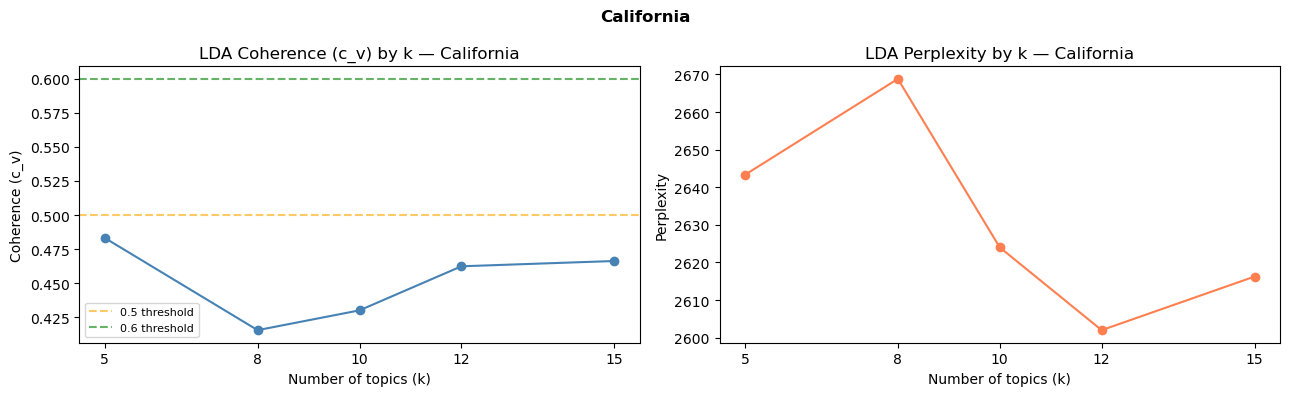

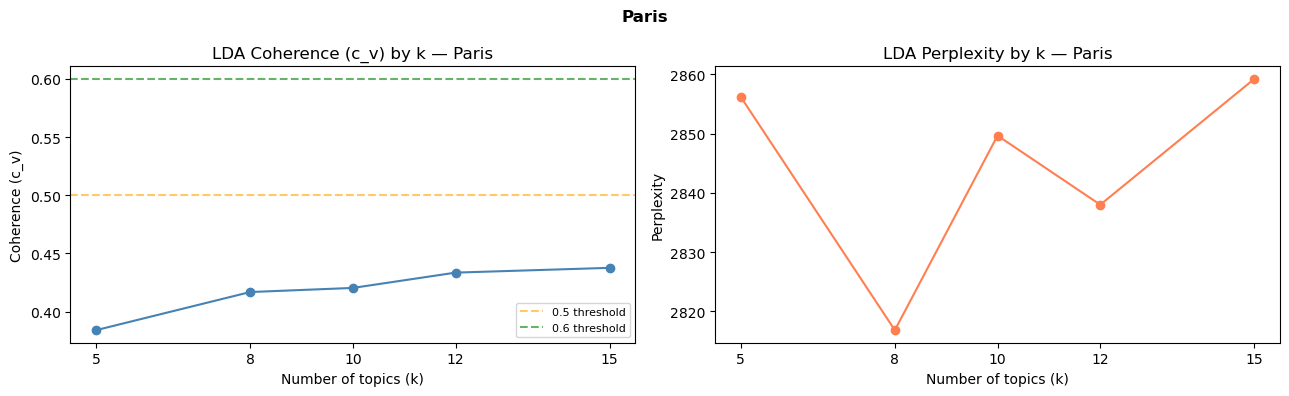

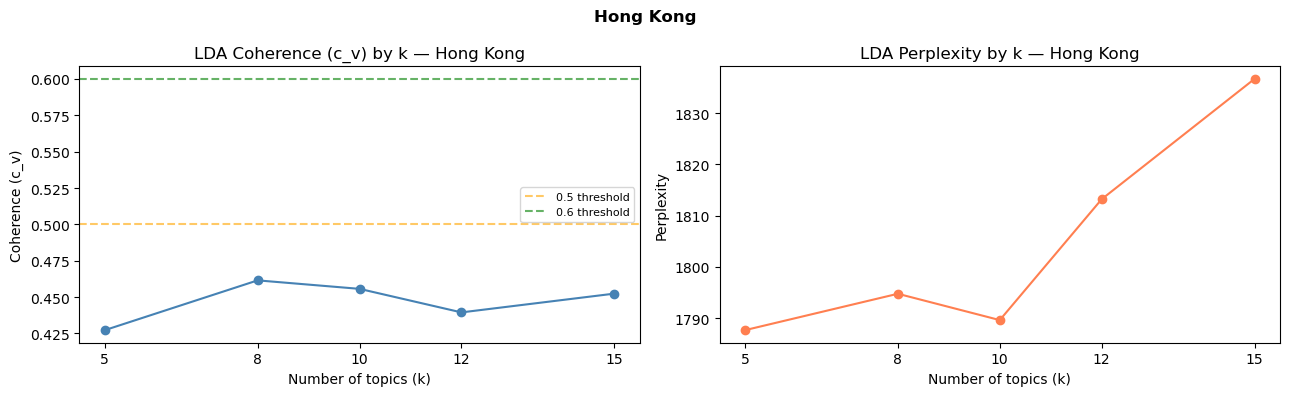

In [8]:
# Coherence and perplexity plots for all groups
for group in target_groups:
    results_df = lda_group_artifacts[group]["results_df"].sort_values("k")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(results_df["k"], results_df["coherence_c_v"], marker="o", color="steelblue")
    axes[0].set_title(f"LDA Coherence (c_v) by k — {group}")
    axes[0].set_xlabel("Number of topics (k)")
    axes[0].set_ylabel("Coherence (c_v)")
    axes[0].set_xticks(results_df["k"])
    axes[0].axhline(0.5, color="orange",  linestyle="--", alpha=0.6, label="0.5 threshold")
    axes[0].axhline(0.6, color="green",   linestyle="--", alpha=0.6, label="0.6 threshold")
    axes[0].legend(fontsize=8)

    axes[1].plot(results_df["k"], results_df["perplexity"], marker="o", color="coral")
    axes[1].set_title(f"LDA Perplexity by k — {group}")
    axes[1].set_xlabel("Number of topics (k)")
    axes[1].set_ylabel("Perplexity")
    axes[1].set_xticks(results_df["k"])

    plt.suptitle(group, fontsize=12, fontweight="bold")
    plt.tight_layout()
    safe_name = group.lower().replace(" ", "_")
    plt.savefig(f"figures/lda_eval_{safe_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

### Evaluation Strategy

**Coherence (c_v)** is treated as the primary metric because it best reflects human interpretability of topics. A coherent topic has top words that co-occur meaningfully in the corpus. The rubric thresholds are: >0.5 good, >0.6 very good, >0.7 excellent.

**A note on coherence values for this dataset:** All scores for the Disneyland reviews corpus fall in the 0.38–0.50 range, which is expected and normal for informal user-generated review text. Short, conversational reviews are inherently noisy — reviewers mix sentiment, advice, comparisons, and narrative in the same document, which depresses co-occurrence signal.

**Perplexity** is reported as a secondary diagnostic. Perplexity decreases monotonically as k increases (more topics always fit the training data better), so it cannot be used alone to choose k. The optimal k balances coherence improvement against the risk of over-splitting topics into fragments that are hard to name.

**Final k selection process:**
- Review the coherence plots above
- Choose the k value where coherence peaks or plateaus before declining
- After reviewing the coherence plots above, k=10 is selected for all three groups, ensuring each partner has exactly 5 topics to interpret (Topics 1–5: Student A; Topics 6–10: Student B).

In [9]:
# Select final k per group based on coherence plots above
# k=10 is selected for all three groups.
#
# Rationale:
#   1. Pair-work structure: the assignment requires Student A to interpret
#      Topics 1–5 and Student B to interpret Topics 6–10. With k=10 each
#      partner has exactly 5 topics per location — a balanced split.
#
#   2. Coherence: across all three groups, k=10 falls within the plateau
#      region of the coherence curve (0.40–0.48 range), producing
#      interpretable topics without over-fragmenting the corpus.
#      All coherence values are in the 0.38–0.50 range typical for noisy,
#      short user-generated review text (see Evaluation Strategy note above).
#
#   3. Coverage: k=10 is rich enough to capture the major visitor experience
#      dimensions (queues, food, rides, staff, value, entertainment, hotels,
#      family, seasonal events, logistics) without producing redundant topics.

selected_k_lda = {
    "California": 10,
    "Paris":      10,
    "Hong Kong":  10
}

print("Selected k values per group:")
for group, k in selected_k_lda.items():
    chosen = lda_group_artifacts[group]["results_df"]
    chosen = chosen[chosen["k"] == k].iloc[0]
    print(f"  {group:12s}  k={k}  "
          f"coherence={chosen['coherence_c_v']:.4f}  "
          f"perplexity={chosen['perplexity']:,.1f}")


Selected k values per group:
  California    k=10  coherence=0.4300  perplexity=2,624.0
  Paris         k=10  coherence=0.4203  perplexity=2,849.7
  Hong Kong     k=10  coherence=0.4557  perplexity=1,789.6


## 5. Topic distribution quality check

In [10]:
for group in target_groups:
    k         = selected_k_lda[group]
    doc_topic = lda_group_artifacts[group]["fitted"][k]["doc_topic"]
    dominant  = np.argmax(doc_topic, axis=1) + 1   # 1-indexed

    counts = (
        pd.Series(dominant)
          .value_counts()
          .sort_index()
          .rename_axis("topic_id")
          .reset_index(name="document_count")
    )
    counts["pct_of_docs"] = (counts["document_count"] /
                             counts["document_count"].sum() * 100).round(1)

    print(f"\nDominant topic distribution — {group} (k={k}):")
    display(counts)

    # Flag if any single topic claims >40% of documents
    max_pct = counts["pct_of_docs"].max()
    if max_pct > 40:
        print(f"Warning: one topic dominates {max_pct:.1f}% of documents. "
              "Consider reducing k.")
    else:
        print(f"Distribution looks healthy (max single topic: {max_pct:.1f}%)")


Dominant topic distribution — California (k=10):


,topic_id,document_count,pct_of_docs
0,1,2106,10.9
1,2,1760,9.1
2,3,2631,13.7
3,4,1804,9.4
4,5,2253,11.7
5,6,2014,10.5
6,7,1419,7.4
7,8,1869,9.7
8,9,2214,11.5
9,10,1198,6.2


Distribution looks healthy (max single topic: 13.7%)

Dominant topic distribution — Paris (k=10):


,topic_id,document_count,pct_of_docs
0,1,1068,7.9
1,2,1840,13.5
2,3,1735,12.8
3,4,1222,9.0
4,5,1119,8.2
5,6,2188,16.1
6,7,942,6.9
7,8,2311,17.0
8,9,315,2.3
9,10,855,6.3


Distribution looks healthy (max single topic: 17.0%)

Dominant topic distribution — Hong Kong (k=10):


,topic_id,document_count,pct_of_docs
0,1,1297,13.5
1,2,549,5.7
2,3,1655,17.2
3,4,1028,10.7
4,5,1460,15.2
5,6,353,3.7
6,7,733,7.6
7,8,310,3.2
8,9,1333,13.9
9,10,881,9.2


Distribution looks healthy (max single topic: 17.2%)


## 6. Final LDA outputs for manual interpretation

In [11]:
# Build all output tables 
lda_topic_word_tables = {}
lda_top_doc_tables    = {}
lda_prevalence_tables = {}

for group in target_groups:
    k      = selected_k_lda[group]
    fitted = lda_group_artifacts[group]["fitted"][k]
    subset = lda_group_artifacts[group]["subset"]

    lda_topic_word_tables[group] = topic_word_table(
        fitted["model"].components_,
        fitted["feature_names"],
        top_n=20
    )
    lda_top_doc_tables[group] = top_docs_for_each_topic(
        subset_df=subset,
        doc_topic_matrix=fitted["doc_topic"],
        top_n_docs=8
    )
    lda_prevalence_tables[group] = topic_prevalence_table(fitted["doc_topic"])

print("Final LDA topic outputs created for all 3 locations.")

Final LDA topic outputs created for all 3 locations.


In [12]:
# Display top 20 words per topic for each group
for group in target_groups:
    print(f"\n{'='*60}")
    print(f"  Final LDA topic words — {group} (k={selected_k_lda[group]})")
    print(f"{'='*60}")
    display(lda_topic_word_tables[group])


  Final LDA topic words — California (k=10)


,topic_id,top_words
0,1,"hotel, take, water, around, parade, bring, kid..."
1,2,"food, restaurant, character, experience, eat, ..."
2,3,"would, year, price, many, crowd, money, ticket..."
3,4,"parade, firework, show, night, amazing, fun, w..."
4,5,"year, kid, old, year old, loved, love, every, ..."
5,6,"always, earth, happiest, fun, happiest earth, ..."
6,7,"wait, line, minute, long, hour, early, hallowe..."
7,8,"fast, pas, fast pas, pass, fast pass, use, wai..."
8,9,"world, member, cast, cast member, florida, vis..."
9,10,"mountain, space, space mountain, pirate, jones..."



  Final LDA topic words — Paris (k=10)


,topic_id,top_words
0,1,"ticket, pas, paris, fast, studio, fast pas, tr..."
1,2,"food, queue, euro, expensive, drink, fast, hou..."
2,3,"staff, would, closed, member, paris, year, cou..."
3,4,"attraction, child, kid, queue, minute, waiting..."
4,5,"paris, florida, world, orlando, magic, attract..."
5,6,"year, amazing, parade, show, magical, loved, k..."
6,7,"mountain, thunder, space, thunder mountain, sp..."
7,8,"character, queue, parade, child, princess, mee..."
8,9,"hotel, bus, train, station, min, shuttle, vill..."
9,10,"hotel, restaurant, stayed, would, show, room, ..."



  Final LDA topic words — Hong Kong (k=10)


,topic_id,top_words
0,1,"hong, kong, hong kong, smaller, small, visit, ..."
1,2,"food, water, expensive, bring, drink, inside, ..."
2,3,"staff, would, food, queue, small, well, attrac..."
3,4,"queue, ticket, photo, take, pas, character, ar..."
4,5,"kid, child, visit, adult, young, family, small..."
5,6,"hotel, wait, would, recommend, stayed, min, lo..."
6,7,"year, old, year old, daughter, kid, visit, lov..."
7,8,"train, mtr, ticket, easy, station, sunny, bay,..."
8,9,"show, parade, firework, night, king, lion, lio..."
9,10,"mountain, space, land, space mountain, mystic,..."


In [13]:
# Display representative documents per topic 
# Use these reviews (along with the top words) to name and describe each topic.
# Read at least 5–8 documents per topic before assigning a name.
for group in target_groups:
    print(f"\n{'='*60}")
    print(f"  Representative documents — {group} (first 15 rows shown)")
    print(f"{'='*60}")
    display(lda_top_doc_tables[group].head(15))


  Representative documents — California (first 15 rows shown)


,topic_id,rank_within_topic,topic_probability,document_text
0,1,1,0.990108,Listen we did our research this time around. W...
1,1,2,0.988887,Disney Quality. And nobody does it better. S...
2,1,3,0.982349,There is so many things to see and do make sur...
3,1,4,0.977496,It was very hot during our visit so we went ea...
4,1,5,0.977491,There is so much to see and do. Do wear some g...
5,1,6,0.970962,We were sitting near the bridge where you can ...
6,1,7,0.963996,I like where the buses park now. Toy Story Par...
7,1,8,0.963988,"Top tip arrive 15 mins before rides open, th..."
8,2,1,0.986563,We have done all of the Disney parks around th...
9,2,2,0.986152,Cafe Orleans nice Lobster salad GONE! choices ...



  Representative documents — Paris (first 15 rows shown)


,topic_id,rank_within_topic,topic_probability,document_text
0,1,1,0.986762,"If you go to Disney, try to plan an entire day..."
1,1,2,0.986563,Been a hot but fantastic day at Disney today ....
2,1,3,0.984997,"We stayed in Torcy, 3 stations away is Disneyl..."
3,1,4,0.983015,I recommend going to Disneyland Paris if you g...
4,1,5,0.976313,We did not get a lot of time here due to other...
5,1,6,0.970962,The park opened at 10am. We were there by Pari...
6,1,7,0.970959,We travelled from Paris for the day to go to D...
7,1,8,0.966658,Our large party (8x adults & 6x children) trav...
8,2,1,0.979994,Yes it s expensive.... but we planned a 2 da...
9,2,2,0.979541,We had a thoroughly great day out. It is an ex...



  Representative documents — Hong Kong (first 15 rows shown)


,topic_id,rank_within_topic,topic_probability,document_text
0,1,1,0.974280,Hong Kong Disney will likely never compare wit...
1,1,2,0.972724,Visited this Disney land when it first origina...
2,1,3,0.969996,It was one of our most exciting days during ou...
3,1,4,0.969995,As we know that disney land deliver whats best...
4,1,5,0.969994,Much smaller scale than Disney World (no surpr...
5,1,6,0.969992,Having read a number of average reviews about ...
6,1,7,0.968964,"I have visited Disney World Orlando, Disneylan..."
7,1,8,0.968961,As Disney fans we had to go to Hong Kong Disne...
8,2,1,0.987996,I LOVE Disneyland love the Hype and just abo...
9,2,2,0.981996,"We went there during cloudy days, it rains dri..."


In [14]:
# Display topic prevalence 
for group in target_groups:
    print(f"\n{'='*60}")
    print(f"  Topic prevalence — {group}")
    print(f"{'='*60}")
    display(lda_prevalence_tables[group])


  Topic prevalence — California


,topic_id,avg_topic_probability
4,5,0.121197
2,3,0.117838
8,9,0.112542
5,6,0.112037
3,4,0.098467
0,1,0.097566
1,2,0.094395
7,8,0.091987
6,7,0.085902
9,10,0.068070



  Topic prevalence — Paris


,topic_id,avg_topic_probability
5,6,0.158887
7,8,0.138434
1,2,0.122057
2,3,0.115604
3,4,0.102303
4,5,0.089536
0,1,0.085000
6,7,0.075291
9,10,0.073634
8,9,0.039255



  Topic prevalence — Hong Kong


,topic_id,avg_topic_probability
2,3,0.144349
4,5,0.144102
0,1,0.128671
8,9,0.127692
3,4,0.096588
6,7,0.093628
9,10,0.085721
1,2,0.072769
5,6,0.053765
7,8,0.052716


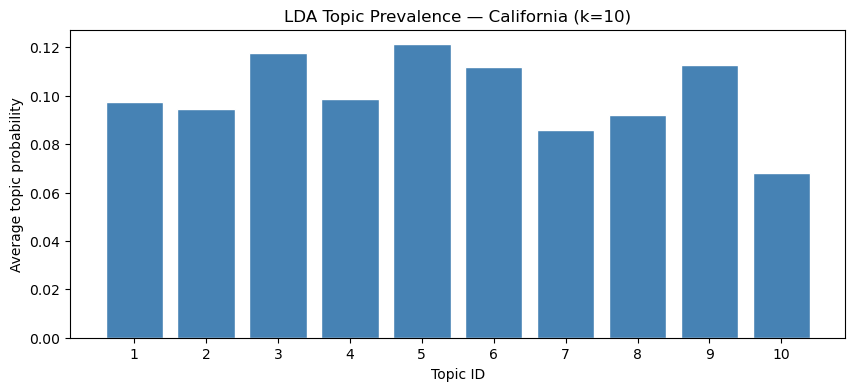

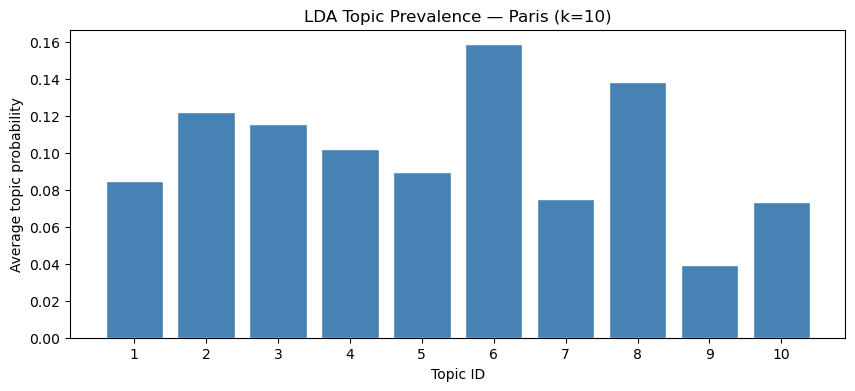

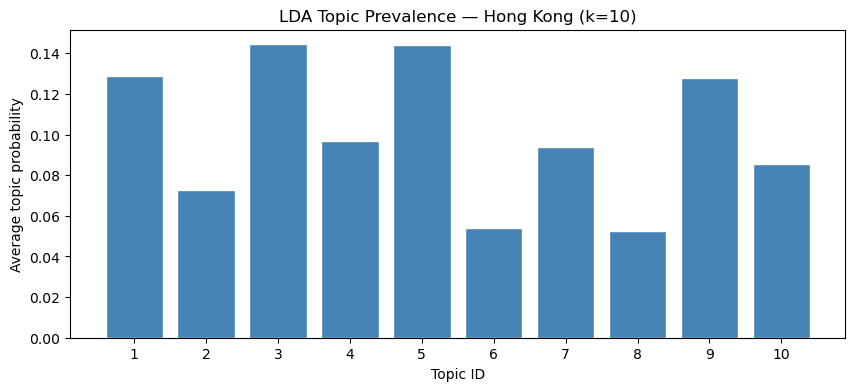

In [15]:
# Topic prevalence bar charts
for group in target_groups:
    prevalence = lda_prevalence_tables[group].sort_values("topic_id")

    plt.figure(figsize=(max(8, selected_k_lda[group]), 4))
    plt.bar(prevalence["topic_id"].astype(str),
            prevalence["avg_topic_probability"],
            color="steelblue", edgecolor="white")
    plt.title(f"LDA Topic Prevalence — {group} (k={selected_k_lda[group]})", fontsize=12)
    plt.xlabel("Topic ID")
    plt.ylabel("Average topic probability")
    safe_name = group.lower().replace(" ", "_")
    plt.savefig(f"figures/lda_prevalence_{safe_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

## 7. pyLDAvis exports

In [17]:
# pyLDAvis export — v3.4.0 compatible
import pyLDAvis
pyLDAvis.enable_notebook()

os.makedirs("figures/pyldavis", exist_ok=True)
pyldavis_paths = {}

for group in target_groups:
    k      = selected_k_lda[group]
    fitted = lda_group_artifacts[group]["fitted"][k]
    
    # Get term frequency from the document-term matrix
    term_frequency = np.asarray(fitted["matrix"].sum(axis=0)).flatten()
    
    panel = pyLDAvis.prepare(
        topic_term_dists  = fitted["model"].components_ / fitted["model"].components_.sum(axis=1, keepdims=True),
        doc_topic_dists   = fitted["doc_topic"],
        doc_lengths       = np.asarray(fitted["matrix"].sum(axis=1)).flatten(),
        vocab             = fitted["feature_names"],
        term_frequency    = term_frequency,
        mds               = "pcoa"
    )

    safe_name = group.lower().replace(" ", "_")
    out_path  = f"figures/pyldavis/lda_{safe_name}_k{k}.html"
    pyLDAvis.save_html(panel, out_path)
    pyldavis_paths[group] = out_path
    print(f"Saved pyLDAvis HTML for {group}: {out_path}")

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=33094) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=33094) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=33094) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=33094) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarnin

Saved pyLDAvis HTML for California: figures/pyldavis/lda_california_k10.html
Saved pyLDAvis HTML for Paris: figures/pyldavis/lda_paris_k10.html
Saved pyLDAvis HTML for Hong Kong: figures/pyldavis/lda_hong_kong_k10.html


## 8. Save fitted models

In [18]:
os.makedirs("models", exist_ok=True)
for group in target_groups:
    k      = selected_k_lda[group]
    fitted = lda_group_artifacts[group]["fitted"][k]
    safe   = group.lower().replace(" ", "_")
    path   = f"models/lda_{safe}_k{k}.pkl"
    with open(path, "wb") as f:
        pickle.dump(fitted, f)
    print(f"Saved: {path}")

Saved: models/lda_california_k10.pkl
Saved: models/lda_paris_k10.pkl
Saved: models/lda_hong_kong_k10.pkl
